In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

2025-02-12 11:20:31.027692: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-12 11:20:31.044713: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-12 11:20:31.145709: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739348431.276837    8046 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739348431.311901    8046 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-12 11:20:31.492251: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [2]:
df = pd.read_csv('baringo-data.csv')

In [3]:
# Convert 'time' column to datetime
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4018 entries, 2010-01-01 to 2020-12-31
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     4018 non-null   int64  
 1   temperature    4018 non-null   float64
 2   dew_point      4018 non-null   float64
 3   humidity       4018 non-null   float64
 4   wind_speed     4018 non-null   float64
 5   pressure       4018 non-null   float64
 6   precipitation  4018 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 251.1 KB


### Factors that influence the occurrence of drought
* **Precipitation (Inverse)**: The less rain, the more likely a drought.
* Temperature: High temperatures increase evaporation, worsening drought.
* Humidity (Inverse): Low humidity means dry air, a key drought indicator.
* Pressure: High pressure is linked to stable, dry weather patterns.

In [4]:
def calculate_drought_probability(df):
    df['7_day_cum_precip'] = df['precipitation'].rolling(window=7).sum()

    # Normalize features (min-max scaling)
    df['norm_precip'] = 1 - (df['7_day_cum_precip'] / df['7_day_cum_precip'].max())  # Inverse: lower precipitation → higher drought risk
    df['norm_temp'] = df['temperature'] / df['temperature'].max()
    df['norm_humidity'] = 1 - (df['humidity'] / df['humidity'].max())  # Inverse: lower humidity → higher drought risk
    df['norm_pressure'] = df['pressure'] / df['pressure'].max()  # Higher pressure → more drought risk

    # Weighted sum of features (tuned weights based on analysis)
    df['drought_probability'] = (
        (df['norm_precip'] * 0.5) +  
        (df['norm_temp'] * 0.3) +  
        (df['norm_humidity'] * 0.15) +  
        (df['norm_pressure'] * 0.05)  
    )

    # Clip values to ensure probability range (0 to 1)
    df['drought_probability'] = df['drought_probability'].clip(0, 1)

    return df

# Apply drought probability function
df = calculate_drought_probability(df)


In [8]:
# Select features and target
features = ['temperature', 'dew_point', 'humidity', 'wind_speed', 'pressure', 'precipitation']
target = 'drought_probability'

In [9]:
# Normalize features
scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

In [10]:
# Prepare sequences for LSTM
sequence_length = 15  # Use past 15 days for prediction
def create_sequences(data, target, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(target[i+seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(df[features].values, df[target].values, sequence_length)

# Split data into train and test sets
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [11]:
# Build LSTM model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(sequence_length, len(features))),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Output is probability (0 to 1)
])

# Compile model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))


2025-02-12 11:37:09.354048: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/ronny/.local/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - loss: 0.0103 - mae: 0.0775 - val_loss: 0.0030 - val_mae: 0.0361
Epoch 2/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0027 - mae: 0.0397 - val_loss: 0.0014 - val_mae: 0.0274
Epoch 3/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0016 - mae: 0.0308 - val_loss: 0.0011 - val_mae: 0.0236
Epoch 4/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0012 - mae: 0.0269 - val_loss: 0.0011 - val_mae: 0.0227
Epoch 5/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0012 - mae: 0.0254 - val_loss: 9.8840e-04 - val_mae: 0.0225
Epoch 6/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0010 - mae: 0.0239 - val_loss: 0.0011 - val_mae: 0.0259
Epoch 7/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.0010 - mae: 0.0246 - val_loss: 9.4910e-04 - val_mae: 0.0231
Epoch 8/50
201/201 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 9.4401e-04 - mae: 0.0231 - val_loss: 9.4781e-04 - val_mae: 0.0217
Epoch 9/50
201/201 ━━━━━━━━━━━━

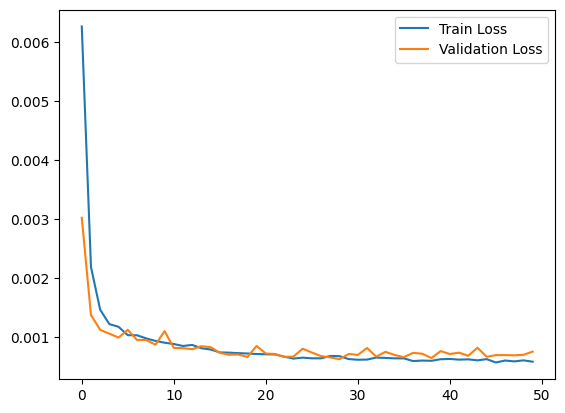

In [12]:
# Plot training loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

In [13]:
# Predict flood probability for the test set
predictions = model.predict(X_test)

predictions = predictions.flatten()

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


In [14]:
# Convert back to percentages
df_test = df.iloc[split+sequence_length:]
df_test = df_test.copy()
df_test['predicted_drought_probability'] = predictions


# Display sample predictions
print(df_test[['drought_probability', 'predicted_drought_probability']].head(30))

            drought_probability  predicted_drought_probability
time                                                          
2018-10-23             0.783056                       0.784286
2018-10-24             0.806254                       0.798513
2018-10-25             0.816260                       0.813695
2018-10-26             0.822212                       0.821238
2018-10-27             0.817979                       0.811122
2018-10-28             0.808874                       0.803495
2018-10-29             0.802923                       0.786135
2018-10-30             0.819385                       0.789392
2018-10-31             0.834641                       0.798754
2018-11-01             0.818304                       0.816216
2018-11-02             0.814021                       0.803570
2018-11-03             0.804312                       0.797629
2018-11-04             0.815861                       0.786418
2018-11-05             0.822767                       0

In [21]:
# View the high risk predictions (likely to experience drought)
high_risk_drought = df_test[df_test['predicted_drought_probability'] > 0.80]

high_risk_drought

,Unnamed: 0,temperature,dew_point,humidity,wind_speed,pressure,precipitation,7_day_cum_precip,norm_precip,norm_temp,norm_humidity,norm_pressure,drought_probability,predicted_drought_probability
time,,,,,,,,,,,,,,
2018-10-25,3219,0.615385,0.578947,0.471429,0.222222,0.482759,0.010978,17.9,0.944753,0.791667,0.377551,0.995015,0.816260,0.813695
2018-10-26,3220,0.615385,0.684211,0.571429,0.259259,0.482759,0.033932,7.1,0.978086,0.791667,0.306122,0.995015,0.822212,0.821238
2018-10-27,3221,0.615385,0.684211,0.614286,0.148148,0.586207,0.023952,6.9,0.978704,0.791667,0.275510,0.996012,0.817979,0.811122
2018-10-28,3222,0.615385,0.736842,0.614286,0.185185,0.586207,0.058882,12.8,0.960494,0.791667,0.275510,0.996012,0.808874,0.803495
2018-11-01,3226,0.692308,0.736842,0.571429,0.333333,0.379310,0.017964,17.7,0.945370,0.833333,0.306122,0.994018,0.818304,0.816216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-27,4013,0.692308,0.421053,0.285714,0.740741,0.172414,0.000000,0.2,0.999383,0.833333,0.510204,0.992024,0.875823,0.852701
2020-12-28,4014,0.692308,0.368421,0.242857,0.740741,0.172414,0.000000,0.1,0.999691,0.833333,0.540816,0.992024,0.880569,0.859814
2020-12-29,4015,0.692308,0.473684,0.357143,0.703704,0.275862,0.000000,0.1,0.999691,0.833333,0.459184,0.993021,0.868374,0.863369


In [16]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error

In [17]:
# Create a copy of the scaled test data to maintain the correct shape
test_data_copy = np.zeros((y_test.shape[0], df[features].shape[1]))  # Same number of columns as original dataset
test_data_copy[:, -1] = y_test  # Only set the target variable (flood probability)
pred_data_copy = test_data_copy.copy()
pred_data_copy[:, -1] = predictions  # Replace with predicted values

In [18]:
# Perform inverse transformation to get actual probabilities
y_test_actual = scaler.inverse_transform(test_data_copy)[:, -1]
y_pred_actual = scaler.inverse_transform(pred_data_copy)[:, -1]

In [19]:
# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
correlation = np.corrcoef(y_test_actual, y_pred_actual)[0, 1]  # Correlation between actual and predicted

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"Correlation: {correlation}")

RMSE: 0.027405655157956677
MAE: 0.02078686070832712
MSE: 0.0007510699346368375
Correlation: 0.9762108121935449


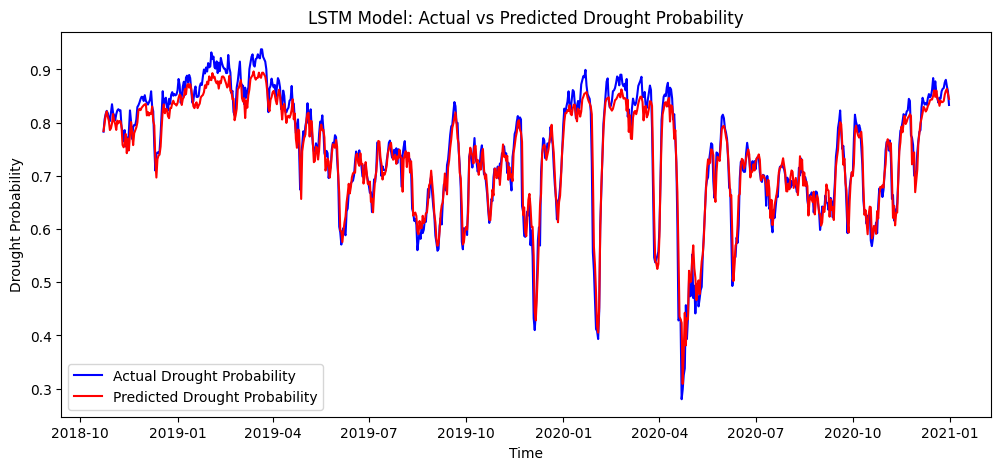

In [20]:
# Visualize Predictions vs Actual
plt.figure(figsize=(12, 5))
plt.plot(df.index[-len(y_test):], y_test_actual, label="Actual Drought Probability", color='blue')
plt.plot(df.index[-len(y_test):], y_pred_actual, label="Predicted Drought Probability", color='red')
plt.legend()
plt.title("LSTM Model: Actual vs Predicted Drought Probability")
plt.xlabel("Time")
plt.ylabel("Drought Probability")
plt.show()